# Initial Data Exploration (Processed Data)

This notebook performs initial exploratory data analysis on NYC TLC trip data.

## Objectives
1. Load and inspect raw data
2. Understand data structure and quality
3. Identify patterns and anomalies
4. Visualize key trends
5. Generate initial insights about hypothesis

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

## 1. Load Data

In [6]:
# Define data paths
PROCESSED_DATA_PATH = Path('../../data/processed')

# List available files
processed_files = list(PROCESSED_DATA_PATH.glob('*.parquet'))
print(f"Found {len(processed_files)} processed data files")
print("\nSample files:")
for f in processed_files[:5]:
    print(f"  - {f.name}")

Found 1 processed data files

Sample files:
  - yellow_tripdata_2024_processed.parquet


In [7]:
# Load all files for initial exploration (no sampling)
print(f"Loading all parquet files: {len(processed_files)}")
for f in processed_files[:10]:
    print(f" - {f.name}")
if len(processed_files) > 10:
    print(f" ... and {len(processed_files) - 10} more")

frames = [pd.read_parquet(f) for f in processed_files]
df = pd.concat(frames, ignore_index=True)

print(f"\nCombined shape: {df.shape}")
print(f"Memory usage: {df.memory_usage().sum() / 1024**2:.2f} MB")


Loading all parquet files: 1
 - yellow_tripdata_2024_processed.parquet

Combined shape: (2788274, 28)
Memory usage: 473.32 MB


## 2. Data Structure and Quality

In [11]:
# Display first few rows
df.head()

,VendorID,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,pickup_location_id,dropoff_location_id,payment_type,...,Airport_fee,trip_duration_seconds,vehicle_type,pickup_year,pickup_month,pickup_day,pickup_hour,pickup_dayofweek,pickup_weekday,time_of_day
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,...,0.0,1188.0,yellow,2024,1,1,0,0,True,night
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,...,0.0,396.0,yellow,2024,1,1,0,0,True,night
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,...,0.0,1075.0,yellow,2024,1,1,0,0,True,night
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,N,79,211,1,...,0.0,498.0,yellow,2024,1,1,0,0,True,night
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,N,211,148,1,...,0.0,366.0,yellow,2024,1,1,0,0,True,night


In [12]:
# Data types and null values
print("Data Info:")
df.info()

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2788274 entries, 0 to 2788273
Data columns (total 28 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   pickup_datetime        datetime64[us]
 2   dropoff_datetime       datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   pickup_location_id     int32         
 8   dropoff_location_id    int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee

In [13]:
# Summary statistics
df.describe()

,VendorID,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,RatecodeID,pickup_location_id,dropoff_location_id,payment_type,fare_amount,...,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,trip_duration_seconds,pickup_year,pickup_month,pickup_day,pickup_hour,pickup_dayofweek
count,2.788274e+06,2788274,2788274,2.788274e+06,2.788274e+06,2.788274e+06,2.788274e+06,2.788274e+06,2.788274e+06,2.788274e+06,...,2.788274e+06,2.788274e+06,2.788274e+06,2.788274e+06,2.788274e+06,2.788274e+06,2.788274e+06,2.788274e+06,2.788274e+06,2.788274e+06
mean,1.755906e+00,2024-01-17 01:16:26.715123,2024-01-17 01:32:04.677346,1.339338e+00,3.245274e+00,2.079187e+00,1.662924e+02,1.655427e+02,1.191394e+00,1.855453e+01,...,9.996500e-01,2.749878e+01,2.310769e+00,1.460165e-01,9.379622e+02,2.024000e+03,1.000044e+00,1.644719e+01,1.424996e+01,2.866940e+00
min,1.000000e+00,2002-12-31 22:59:39,2002-12-31 23:05:41,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,...,-1.000000e+00,-5.750000e+00,-2.500000e+00,-1.750000e+00,1.000000e+00,2.002000e+03,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,2024-01-09 15:39:46,2024-01-09 15:56:55,1.000000e+00,1.000000e+00,1.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,8.600000e+00,...,1.000000e+00,1.545000e+01,2.500000e+00,0.000000e+00,4.270000e+02,2.024000e+03,1.000000e+00,9.000000e+00,1.100000e+01,1.000000e+00
50%,2.000000e+00,2024-01-17 10:41:36,2024-01-17 10:59:47.500000,1.000000e+00,1.670000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.280000e+01,...,1.000000e+00,2.015000e+01,2.500000e+00,0.000000e+00,6.930000e+02,2.024000e+03,1.000000e+00,1.700000e+01,1.500000e+01,3.000000e+00
75%,2.000000e+00,2024-01-24 18:45:44,2024-01-24 19:00:45,1.000000e+00,3.100000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,1.980000e+01,...,1.000000e+00,2.856000e+01,2.500000e+00,0.000000e+00,1.116000e+03,2.024000e+03,1.000000e+00,2.400000e+01,1.900000e+01,5.000000e+00
max,2.000000e+00,2024-02-01 00:01:15,2024-02-01 22:04:34,8.000000e+00,9.900000e+01,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,8.200000e+02,...,1.000000e+00,8.210000e+02,2.500000e+00,1.750000e+00,8.639900e+04,2.024000e+03,1.200000e+01,3.100000e+01,2.300000e+01,6.000000e+00
std,4.295486e-01,NaN,NaN,8.516237e-01,4.398612e+00,9.878081e+00,6.320520e+01,6.918245e+01,4.679261e-01,1.773295e+01,...,2.031359e-02,2.221755e+01,6.615532e-01,4.840005e-01,2.096054e+03,2.047572e-02,2.187305e-02,8.831580e+00,5.636143e+00,1.930063e+00


In [14]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = 100 * missing / len(df)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
}).sort_values('Percentage', ascending=False)

print("Missing Values:")
print(missing_df[missing_df['Percentage'] > 0])

Missing Values:
Empty DataFrame
Columns: [Missing Count, Percentage]
Index: []


## 3. Temporal Patterns

In [15]:
# Extract temporal features
if 'tpep_pickup_datetime' in df.columns:
    df['pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
elif 'lpep_pickup_datetime' in df.columns:
    df['pickup_datetime'] = pd.to_datetime(df['lpep_pickup_datetime'])

df['hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['day'] = df['pickup_datetime'].dt.day

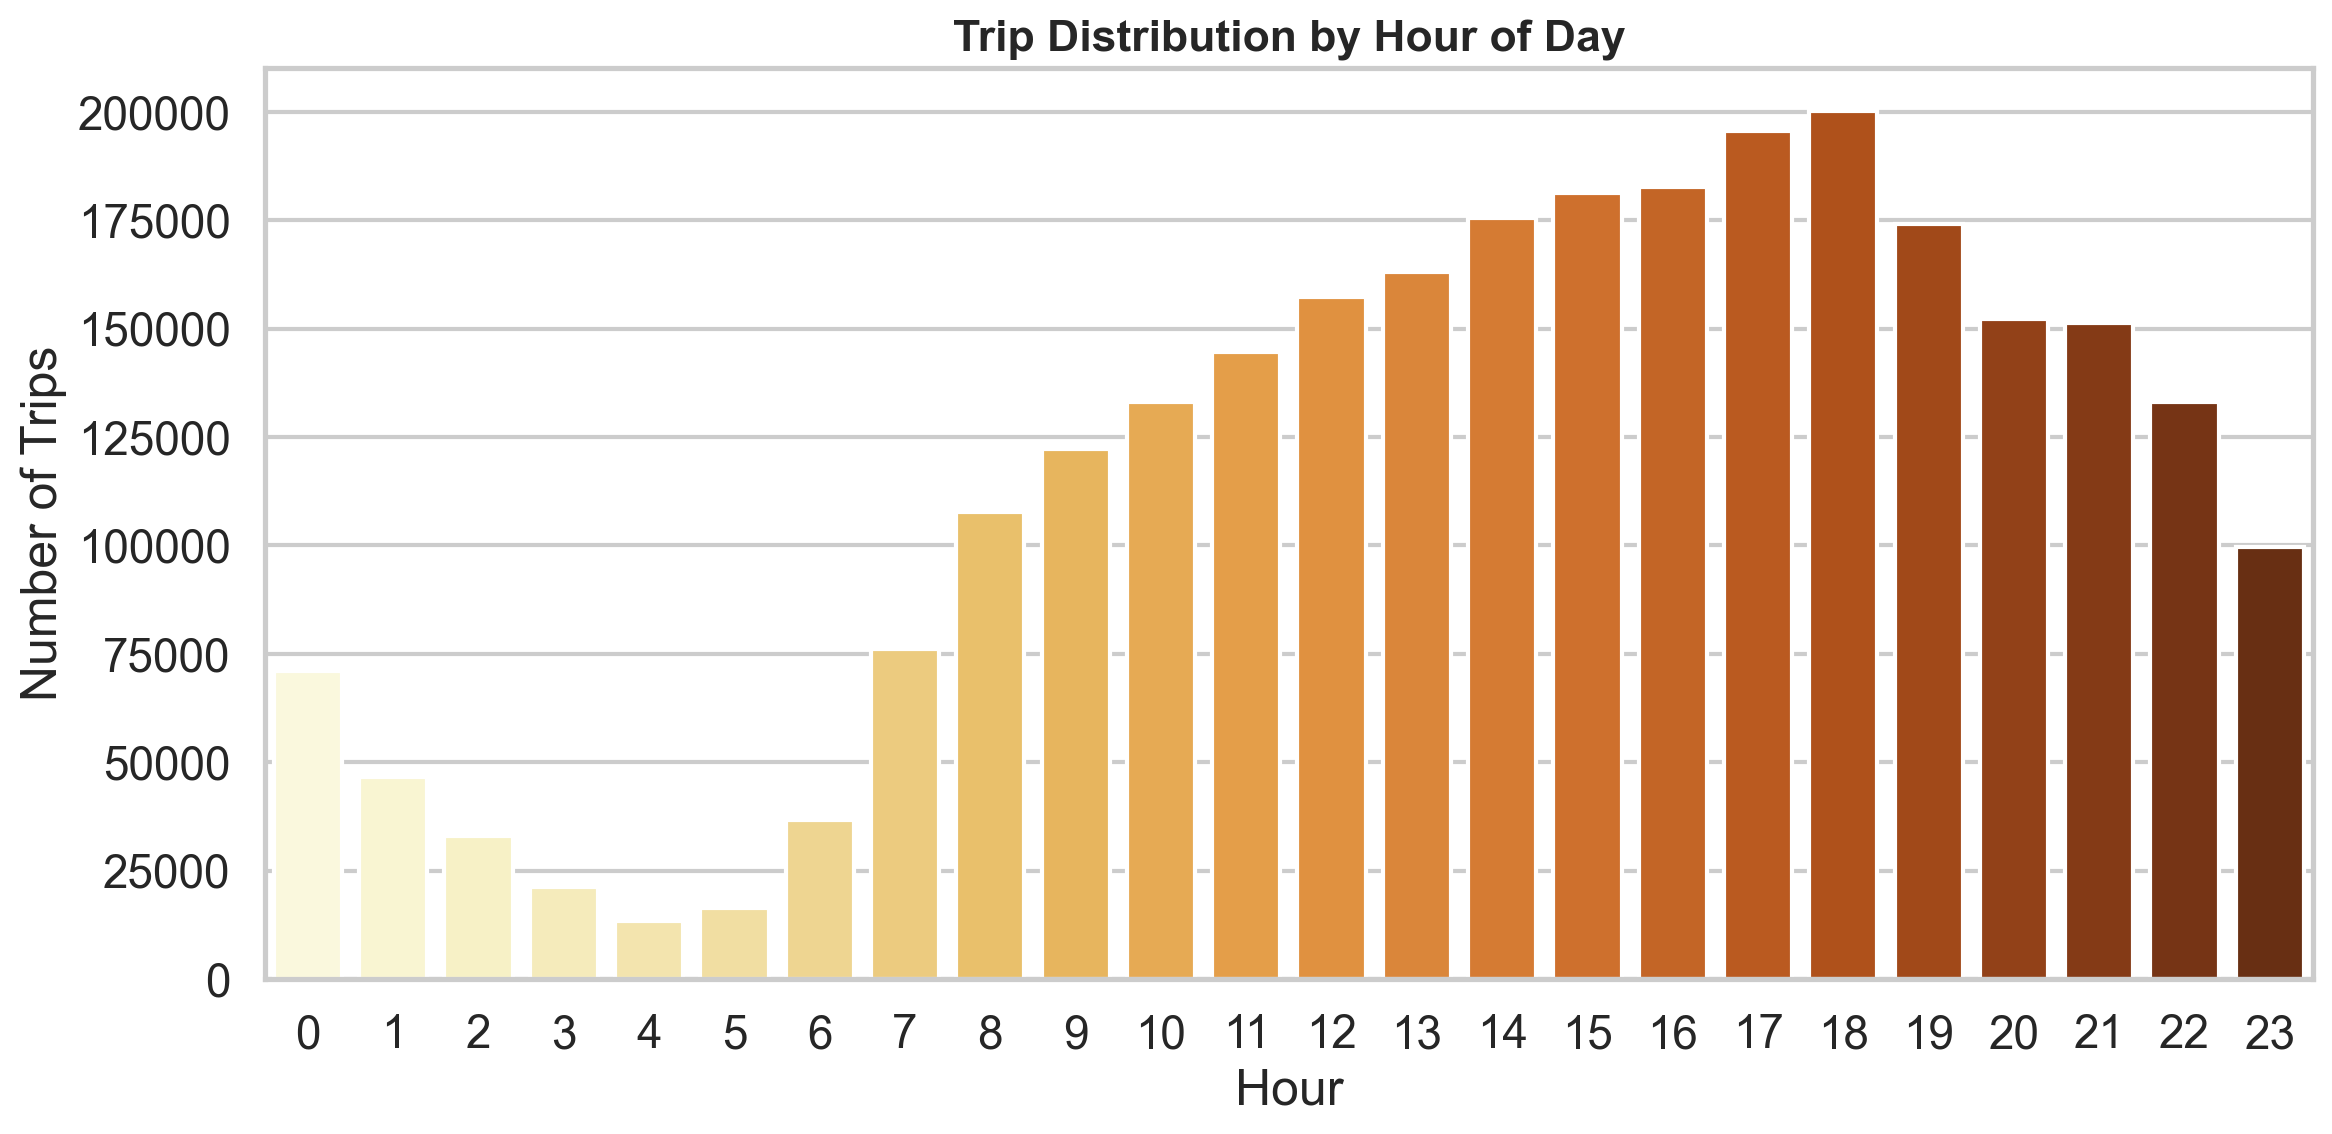

In [37]:
sns.set_theme(style='whitegrid', context='talk')

hour_counts = df['hour'].value_counts().sort_index().reset_index()
hour_counts.columns = ['hour', 'trips']

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=hour_counts, x='hour', y='trips', palette='YlOrBr', ax=ax)

ax.set_title('Trip Distribution by Hour of Day', fontsize=16, weight='bold')
ax.set_xlabel('Hour')
ax.set_ylabel('Number of Trips')

plt.tight_layout()
plt.show()

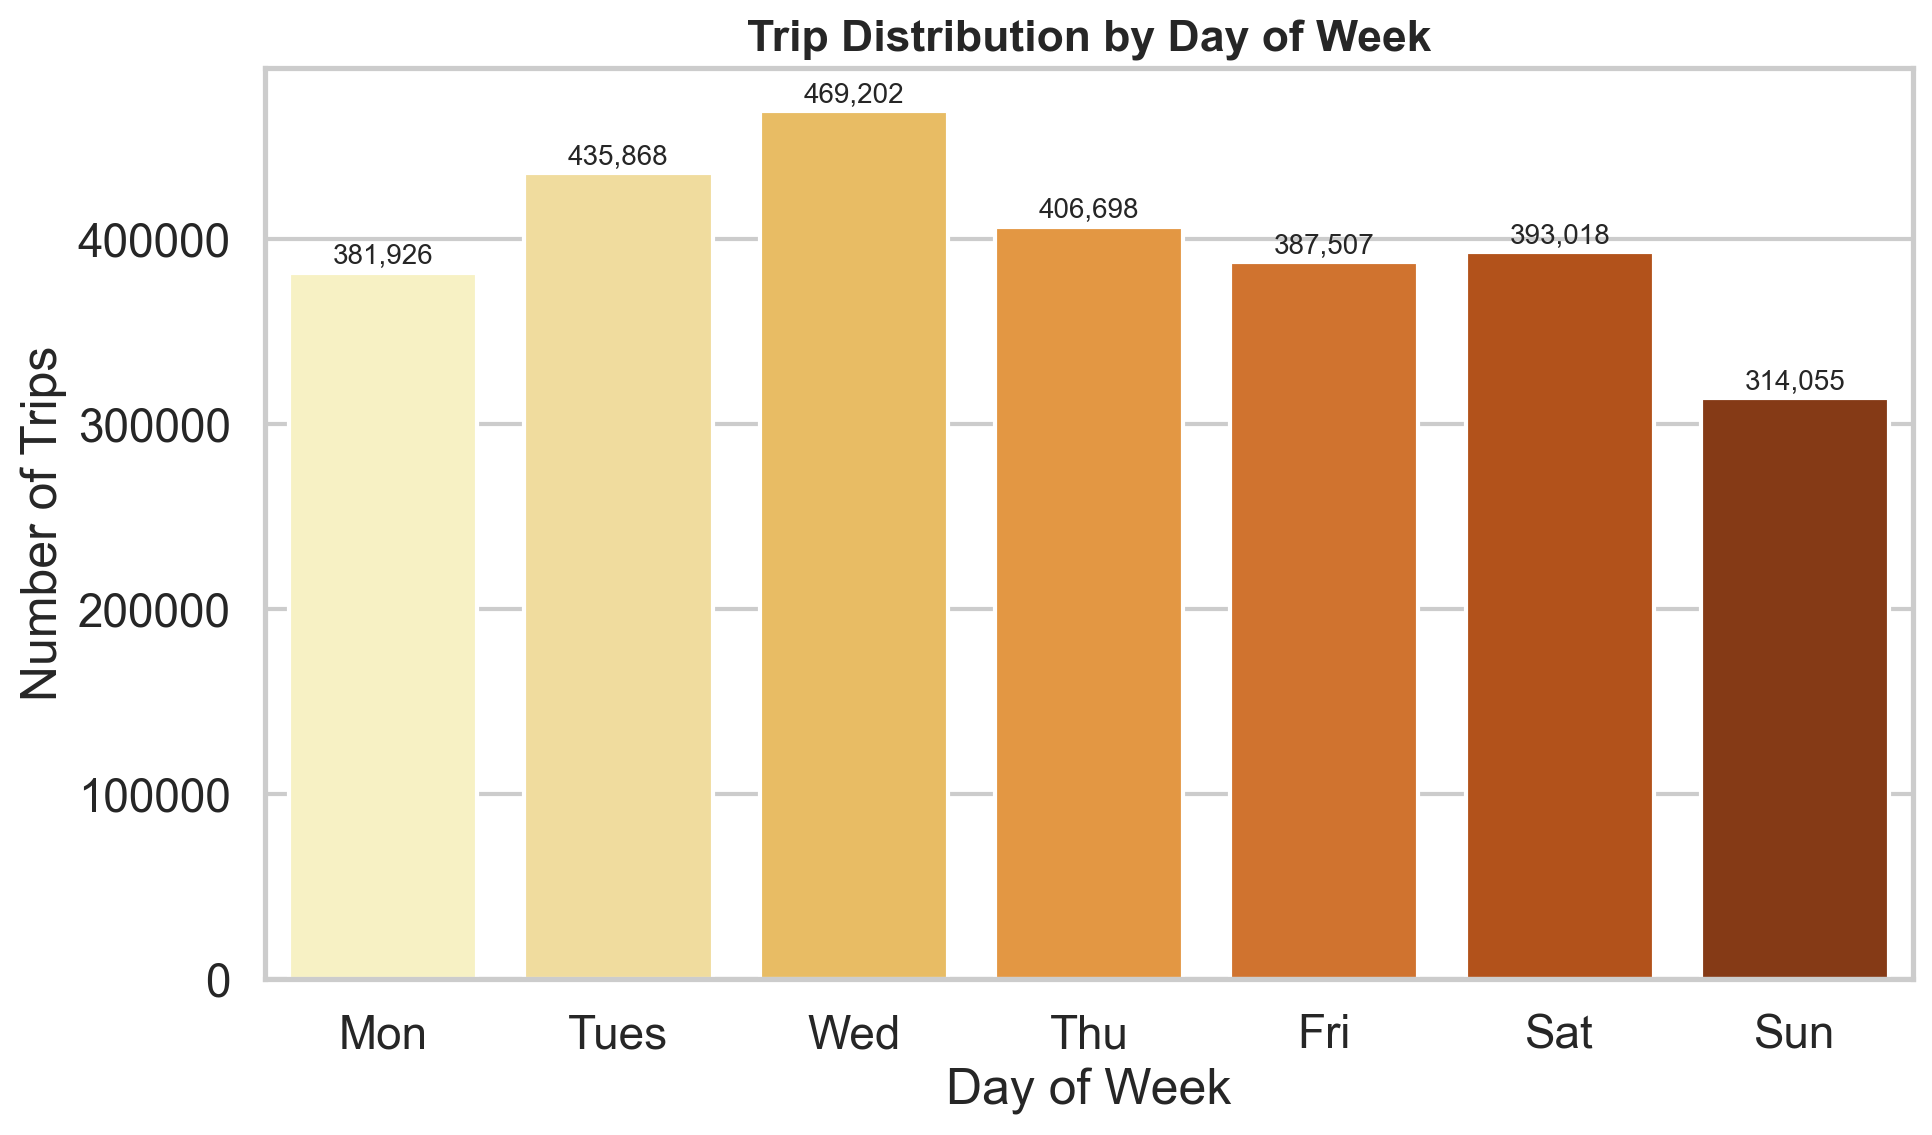

In [35]:
sns.set_theme(style='whitegrid', context='talk')

labels = ['Mon', 'Tues', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
counts = df['day_of_week'].value_counts().sort_index().reset_index()
counts.columns = ['day_idx', 'trips']
counts['day_label'] = labels

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=counts, x='day_label', y='trips', palette='YlOrBr', ax=ax)

ax.set_title('Trip Distribution by Day of Week', fontsize=16, weight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Number of Trips')

for i, v in enumerate(counts['trips']):
    ax.text(i, v + counts['trips'].max()*0.01, f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 4. Trip Characteristics

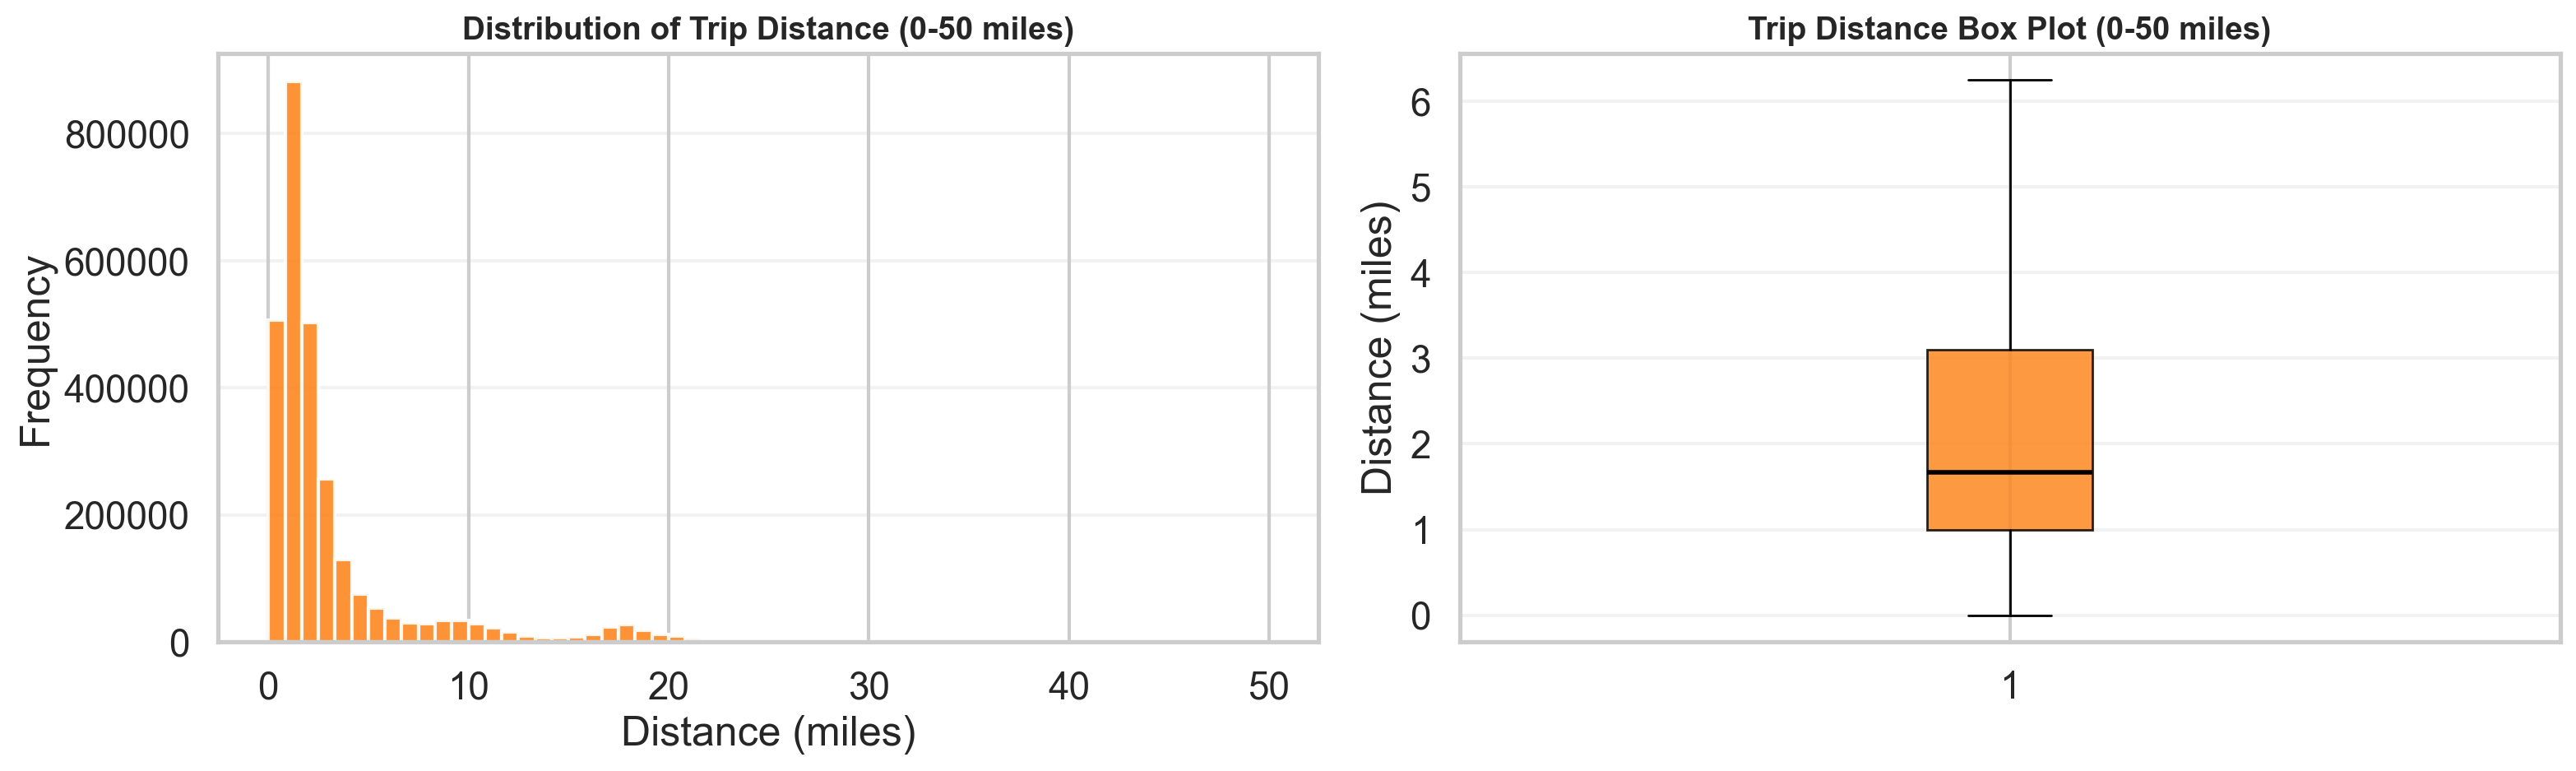

In [34]:
# Distribution of trip distance (cleaner visualization)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Focus plotting range for readability
dist = df['trip_distance'].dropna()
dist_plot = dist[(dist >= 0) & (dist <= 50)]  # adjust upper bound if needed

# Histogram
axes[0].hist(dist_plot, bins=60, color='#FD8720', edgecolor='white', alpha=0.9)
axes[0].set_title('Distribution of Trip Distance (0-50 miles)', fontsize=14, weight='bold')
axes[0].set_xlabel('Distance (miles)')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', alpha=0.25)

# Box plot
axes[1].boxplot(
    dist_plot,
    vert=True,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor='#FD8720', alpha=0.85),
    medianprops=dict(color='black', linewidth=2)
)
axes[1].set_title('Trip Distance Box Plot (0-50 miles)', fontsize=14, weight='bold')
axes[1].set_ylabel('Distance (miles)')
axes[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()


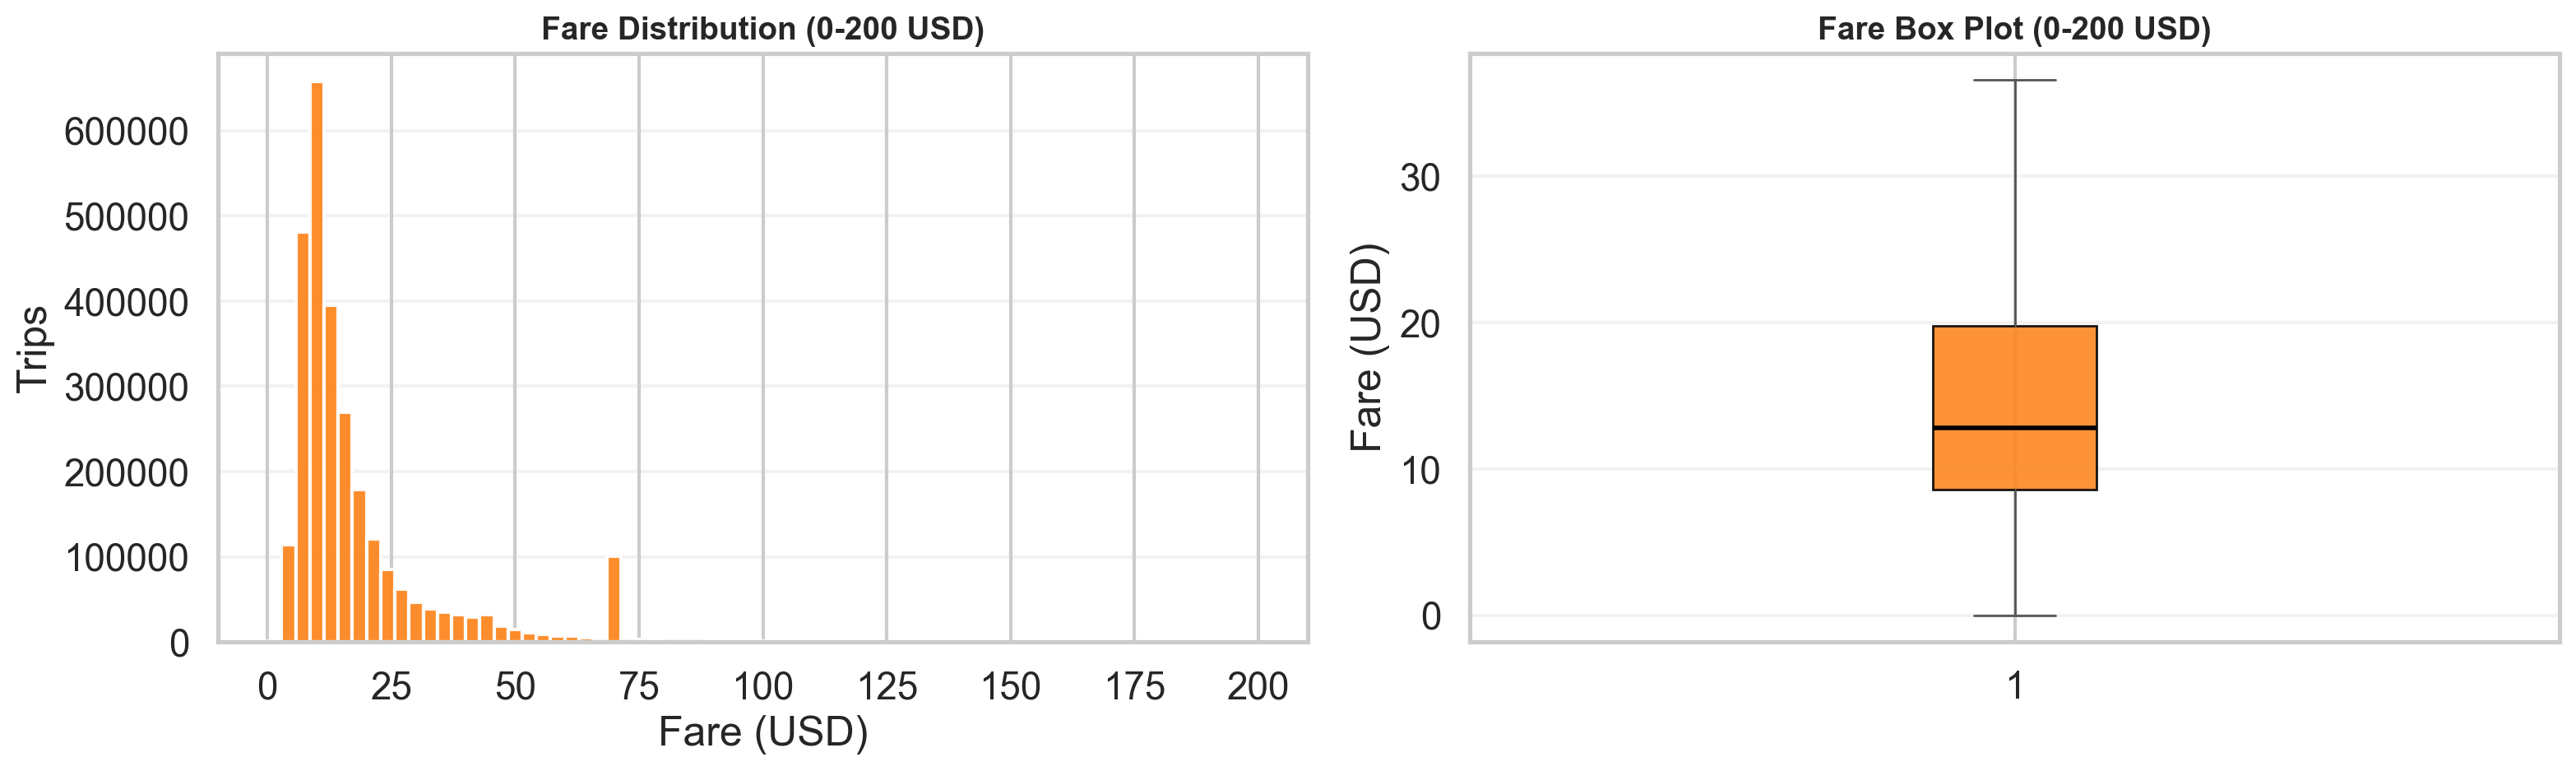

In [33]:
# Cleaner fare plots (focus on realistic range)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

fare = df['fare_amount'].dropna()
fare_plot = fare[(fare >= 0) & (fare <= 200)]   # focus window for readability

# Histogram
axes[0].hist(fare_plot, bins=70, color="#FD8720", edgecolor='white', alpha=0.95)
axes[0].set_title('Fare Distribution (0-200 USD)', fontsize=14, weight='bold')
axes[0].set_xlabel('Fare (USD)')
axes[0].set_ylabel('Trips')
axes[0].grid(axis='y', alpha=0.25)

# Box plot
axes[1].boxplot(
    fare_plot,
    vert=True,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor="#FD8720", alpha=0.9),
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='#555'),
    capprops=dict(color='#555')
)
axes[1].set_title('Fare Box Plot (0-200 USD)', fontsize=14, weight='bold')
axes[1].set_ylabel('Fare (USD)')
axes[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()


## 5. Geographic Patterns

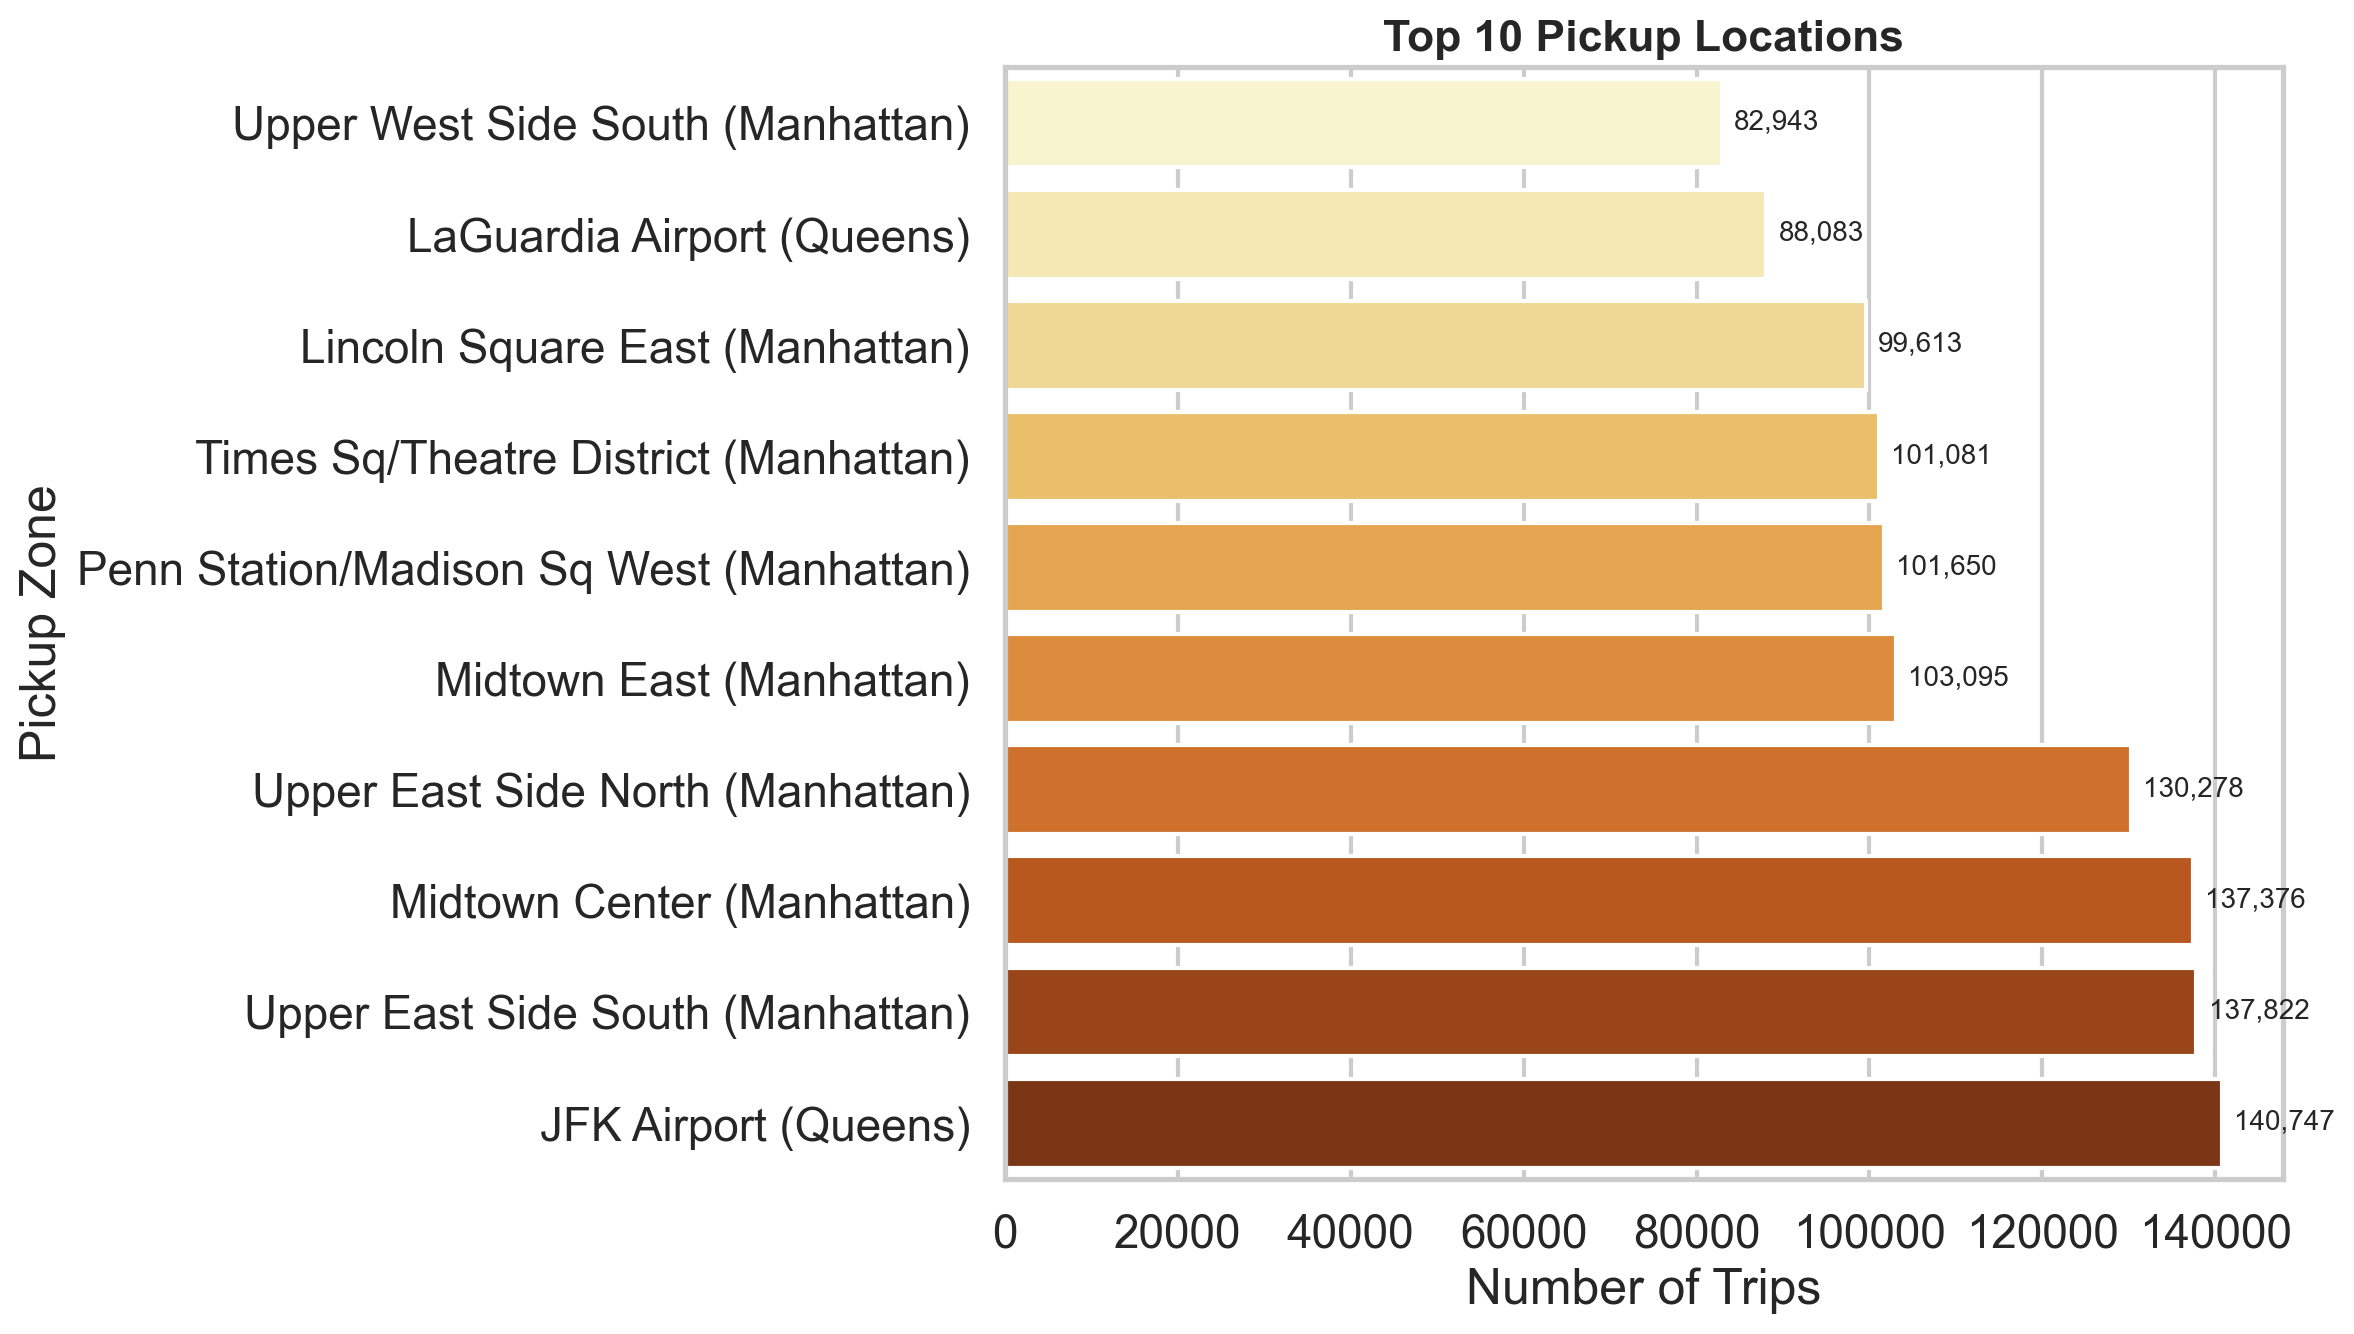

In [28]:
pickup_col = 'pickup_location_id' if 'pickup_location_id' in df.columns else 'PULocationID'
zones = pd.read_csv('../../data/external/taxi_zone_lookup.csv')

top = (
    df[pickup_col].value_counts().head(10)
    .rename_axis('LocationID').reset_index(name='trips')
    .merge(zones[['LocationID', 'Zone', 'Borough']], on='LocationID', how='left')
)

top['label'] = top['Zone'].fillna('Unknown') + ' (' + top['Borough'].fillna('Unknown') + ')'
top = top.sort_values('trips')

sns.set_theme(style='whitegrid', context='talk')
plt.figure(figsize=(12, 7))
ax = sns.barplot(data=top, x='trips', y='label', palette='YlOrBr')

ax.set_title('Top 10 Pickup Locations', fontsize=16, weight='bold')
ax.set_xlabel('Number of Trips')
ax.set_ylabel('Pickup Zone')

for i, v in enumerate(top['trips']):
    ax.text(v + top['trips'].max()*0.01, i, f'{v:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()